# 1. Ingesta, Limpieza y Fusión de Datos (Merge)
En esta sección vamos a:
1. Cargar las dos tablas principales: `Info_Pdv` y `Data_historica`.
2. Convertir la columna `fecha` al formato correcto de tiempo (datetime) para poder hacer análisis de series temporales.
3. Calcular nuestra variable objetivo adicional: `ticket` (ventas_monto / transacciones).
4. Unir ambas tablas usando el `punto_de_venta_id` como llave (Key) para tener un único **Dataframe Maestro**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Cargar las tablas (Reemplaza con el nombre real de tus archivos CSV o Excel)
df_info = pd.read_excel(r"D:\Documents\Roger\Universidad\Proyecto de grado ll\DATA GIG\Base de datos - Proyecto Roger_encriptada febrero.xlsx", sheet_name= 'Info_Pdv')
df_ventas = pd.read_excel(r"D:\Documents\Roger\Universidad\Proyecto de grado ll\DATA GIG\Base de datos - Proyecto Roger_encriptada febrero.xlsx", sheet_name= 'Data_Historica')

# 2. Parseo de fechas (Asumiendo formato Día/Mes/Año por el ejemplo '1/01/2018')
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'], format='%d/%m/%Y', errors='coerce')

# 3. Creación de la variable Ticket
# Usamos np.where para evitar errores de división por cero si algún día hubo 0 transacciones
df_ventas['ticket'] = np.where(df_ventas['transacciones'] > 0, 
                               df_ventas['ventas_monto'] / df_ventas['transacciones'], 
                               0)

# 4. Fusión (Merge) de las tablas
# Usamos un 'left' join para mantener todas las ventas y traer su info geográfica/marca
df_master = pd.merge(df_ventas, df_info, on='punto_de_venta_id', how='left')

# Extraer componentes de la fecha para el análisis de estacionalidad
df_master['Año'] = df_master['fecha'].dt.year
df_master['Mes'] = df_master['fecha'].dt.month
df_master['Dia_Semana'] = df_master['fecha'].dt.dayofweek # 0=Lunes, 6=Domingo

print(f"Dimensiones del DataFrame Maestro: {df_master.shape}")
display(df_master.head())

Dimensiones del DataFrame Maestro: (210969, 13)


,fecha,punto_de_venta_id,canal_id,ventas_monto,transacciones,ticket,ubicacion_id,tipo_pdv_id,marca_id,categoria_id,Año,Mes,Dia_Semana
0,2018-01-01,P1,1,124073367.0,3257.0,38094.371200,U149,T1,M3,C6,2018,1,0
1,2018-02-01,P1,1,105951503.0,2485.0,42636.419718,U149,T1,M3,C6,2018,2,3
2,2018-03-01,P1,1,118043293.0,2713.0,43510.244379,U149,T1,M3,C6,2018,3,3
3,2018-04-01,P1,1,104567988.0,2428.0,43067.540362,U149,T1,M3,C6,2018,4,6
4,2018-05-01,P1,1,107184291.0,2487.0,43097.825090,U149,T1,M3,C6,2018,5,1


# 1.5 Limpieza y Transformación de Identificadores (IDs) 🧹🔢

Al revisar la estructura del dataset maestro, se evidencia que las variables de identificación (`punto_de_venta_id`, `ubicacion_id`, `tipo_pdv_id`, `marca_id`, `categoria_id`) contienen un formato alfanumérico compuesto por una letra indicadora seguida de un número (ej. 'P1', 'U149', '6'). 

Dado que los algoritmos de Machine Learning requieren entradas estrictamente numéricas para optimizar su procesamiento, en esta sección aplicaré expresiones regulares (Regex) para extraer únicamente el componente numérico de estas variables y transformarlas al tipo de dato entero (`int`). Esto evitará la necesidad de realizar codificaciones de etiquetas (*Label Encoding*) más adelante y mantendrá la base de datos ligera.

In [3]:
# ==========================================
# EXTRACCIÓN DE IDs POR POSICIÓN (Slicing)
# ==========================================

columnas_id = [
    'punto_de_venta_id', 
    'ubicacion_id', 
    'tipo_pdv_id', 
    'marca_id', 
    'categoria_id'
]

for col in columnas_id:
    # 1. Convertimos a string y quitamos espacios en blanco accidentales (strip)
    df_master[col] = df_master[col].astype(str).str.strip()
    
    # 2. Tomamos desde el segundo carácter en adelante [1:]
    # Ejemplo: 'P123' -> '123'
    # Usamos pd.to_numeric con 'coerce' por si alguna fila está vacía
    df_master[col] = pd.to_numeric(df_master[col].str[1:], errors='coerce')
    
    # 3. Llenamos nulos con 0 y pasamos a entero
    df_master[col] = df_master[col].fillna(0).astype(int)

print("✅ Limpieza por rebanado (slicing) completada.")

# Verificación de seguridad
display(df_master[columnas_id].head(100))

✅ Limpieza por rebanado (slicing) completada.


,punto_de_venta_id,ubicacion_id,tipo_pdv_id,marca_id,categoria_id
0,1,149,1,3,6
1,1,149,1,3,6
2,1,149,1,3,6
3,1,149,1,3,6
4,1,149,1,3,6
...,...,...,...,...,...
95,2,149,1,3,6
96,2,149,1,3,6
97,2,149,1,3,6
98,2,149,1,3,6


# 1.5 Diagnóstico y Calidad de los Datos (Data Quality Check) 🛡️

Antes de proceder con el análisis exploratorio y la visualización de tendencias, es una buena práctica y un requisito técnico indispensable realizar una auditoría de la calidad del `df_master`. 

En esta sección verificaré:
1. **Valores Nulos (Missing Values):** Para garantizar que no existan huecos de información en las variables clave.
2. **Registros Duplicados:** Para evitar conteos dobles que inflen artificialmente las métricas de ventas y transacciones.
3. **Anomalías Lógicas (Estadística Descriptiva):** Validar que no existan registros físicamente imposibles en la operación (por ejemplo, transacciones negativas o tickets promedio absurdos).

In [4]:
# ==========================================
# DIAGNÓSTICO DE CALIDAD DE DATOS
# ==========================================

# 1. Revisión de Valores Nulos
print("--- 1. VALORES NULOS POR COLUMNA ---")
nulos = df_master.isnull().sum()
if nulos.sum() > 0:
    print("Se encontraron valores nulos en las siguientes columnas:")
    print(nulos[nulos > 0])
else:
    print("✅ ¡Excelente! No hay valores nulos en el dataset maestro.")

# 2. Revisión de Registros Duplicados
print("\n--- 2. REGISTROS DUPLICADOS ---")
duplicados = df_master.duplicated().sum()
if duplicados > 0:
    print(f"⚠️ Se encontraron {duplicados} filas exactamente duplicadas. Se recomienda eliminarlas.")
else:
    print("✅ No se encontraron filas duplicadas.")

# 3. Revisión de Anomalías Lógicas (Valores Negativos o Ceros Extraños)
print("\n--- 3. RESUMEN ESTADÍSTICO (Variables Objetivo) ---")
# Describimos solo las variables numéricas clave, redondeando a 2 decimales para facilitar la lectura
display(df_master[['ventas_monto', 'transacciones', 'ticket']].describe().round(2))

--- 1. VALORES NULOS POR COLUMNA ---
✅ ¡Excelente! No hay valores nulos en el dataset maestro.

--- 2. REGISTROS DUPLICADOS ---
✅ No se encontraron filas duplicadas.

--- 3. RESUMEN ESTADÍSTICO (Variables Objetivo) ---


,ventas_monto,transacciones,ticket
count,2.109690e+05,210969.00,210969.00
mean,8.385295e+07,2421.62,36853.26
std,1.015826e+08,3214.37,16035.86
min,3.703700e+03,0.50,15.25
25%,2.835090e+07,803.00,28899.79
50%,5.421688e+07,1535.00,35580.17
75%,1.027959e+08,2844.39,43100.35
max,1.632023e+09,44888.00,3871481.48


# 1.6 Tratamiento de Anomalías Lógicas y Valores Atípicos (Outliers) 🧹

Al analizar la estadística descriptiva del `df_master`, identifiqué comportamientos ilógicos que violan las reglas de negocio del sector *food service* en Colombia:
1. **Transacciones fraccionadas:** Existen registros con transacciones menores a 1 (ej. 0.50), lo cual es operativamente imposible.
2. **Ticket Promedio irrisorio:** Tickets mínimos de $15 COP, lo que indica transacciones de prueba en los sistemas POS o errores de digitación.
3. **Ticket Promedio exagerado:** Tickets máximos de más de $3.8 millones COP como promedio mensual de una sucursal, lo cual distorsiona la media del mercado.

En esta sección, aplicaré filtros lógicos de negocio para depurar la base de datos, definiendo un umbral mínimo viable de venta y eliminando errores de sistema.

In [5]:
# ==========================================
# INVESTIGACIÓN Y LIMPIEZA DE ANOMALÍAS
# ==========================================

# 1. Cuantificar el tamaño del problema
# Definimos reglas lógicas de negocio para Colombia:
# - Transacciones deben ser enteras y al menos 1.
# - Un ticket promedio menor a $1,000 COP es irreal (ni un producto gancho cuesta eso).
# - Un ticket promedio mensual mayor a $500,000 COP en food service retail es altamente atípico (posibles facturas institucionales B2B, no consumo natural).

anomalias_transacciones = df_master[df_master['transacciones'] < 1]
anomalias_ticket_bajo = df_master[(df_master['ticket'] > 0) & (df_master['ticket'] < 1000)]
anomalias_ticket_alto = df_master[df_master['ticket'] > 500000]

print(f"Registros con transacciones < 1: {len(anomalias_transacciones)}")
print(f"Registros con ticket < $1,000: {len(anomalias_ticket_bajo)}")
print(f"Registros con ticket > $500,000: {len(anomalias_ticket_alto)}")

# 2. Aplicar los filtros de limpieza (Crear un dataset depurado)
df_clean = df_master[
    (df_master['transacciones'] >= 1) & 
    (df_master['ticket'] >= 1000) & 
    (df_master['ticket'] <= 500000)
]

print(f"\nSe han eliminado {len(df_master) - len(df_clean)} registros atípicos/erróneos.")
print(f"Dimensiones del dataset limpio: {df_clean.shape}")

# 3. Verificar el nuevo resumen estadístico
print("\n--- NUEVO RESUMEN ESTADÍSTICO (Depurado) ---")
display(df_clean[['ventas_monto', 'transacciones', 'ticket']].describe().round(2))

# NOTA: Sobreescribimos el df_master con el df_clean para usarlo en el resto del análisis
df_master = df_clean.copy()

Registros con transacciones < 1: 67
Registros con ticket < $1,000: 12
Registros con ticket > $500,000: 5

Se han eliminado 84 registros atípicos/erróneos.
Dimensiones del dataset limpio: (210885, 13)

--- NUEVO RESUMEN ESTADÍSTICO (Depurado) ---


,ventas_monto,transacciones,ticket
count,2.108850e+05,210885.00,210885.00
mean,8.388603e+07,2422.56,36812.24
std,1.015893e+08,3214.67,12090.98
min,3.703700e+03,1.00,1288.29
25%,2.837667e+07,804.00,28898.21
50%,5.424963e+07,1536.00,35576.61
75%,1.028228e+08,2845.00,43095.47
max,1.632023e+09,44888.00,458989.28


# 1.7 Investigación Específica de Valores Máximos (Outliers Residuales) 🔍

Tras la primera depuración, el resumen estadístico muestra que el ticket promedio máximo se ubica en $458,989 COP. Aunque logramos limpiar los extremos absurdos (reduciendo el límite de 3.8 millones a menos de 500 mil), este valor sigue siendo inusualmente alto para un promedio mensual en retail de alimentos. 

A continuación, aislaré este registro específico para identificar la sucursal, la fecha y su contexto operativo (volumen de transacciones). El objetivo es evaluar si corresponde a un comportamiento legítimo (ej. formato premium con pocas ventas corporativas) o si representa una anomalía residual que deba ser excluida para no sesgar el modelo predictivo.

In [6]:
# ==========================================
# INVESTIGACIÓN DEL TICKET MÁXIMO
# ==========================================

# Identificamos el valor exacto del ticket máximo
ticket_max_actual = df_master['ticket'].max()

# Filtramos el DataFrame para traer solo la fila(s) con ese valor
registro_sospechoso = df_master[df_master['ticket'] == ticket_max_actual]

# Seleccionamos las columnas clave para entender el contexto del registro
columnas_contexto = [
    'fecha', 
    'punto_de_venta_id', 
    'marca_id', 
    'categoria_id', 
    'tipo_pdv_id',
    'ventas_monto', 
    'transacciones', 
    'ticket'
]

print("--- DETALLE DEL REGISTRO CON EL TICKET MÁXIMO ---")
display(registro_sospechoso[columnas_contexto])

# (Opcional) Ver si hay otros registros peligrosamente altos (ej. por encima de 200,000)
# para ver si es un caso aislado o un grupo de sucursales.
tickets_muy_altos = df_master[df_master['ticket'] > 200000]
print(f"\nExisten {len(tickets_muy_altos)} registros en toda la historia con un ticket superior a $200,000 COP.")

--- DETALLE DEL REGISTRO CON EL TICKET MÁXIMO ---


,fecha,punto_de_venta_id,marca_id,categoria_id,tipo_pdv_id,ventas_monto,transacciones,ticket
73184,2022-12-01,4395,64,7,1,1.189425e+08,259.14,458989.277649



Existen 13 registros en toda la historia con un ticket superior a $200,000 COP.


# 1.8 Eliminación de Errores de Digitación (Limpieza Dirigida) 🗑️

Tras realizar una inspección manual del registro con el ticket máximo ($458,989 COP), identifiqué que corresponde a una sucursal del segmento de pizzerías (Categoría C7, Marca M64) en el mes de diciembre de 2022. 

Dado el modelo de negocio de esta categoría, un ticket promedio mensual de esa magnitud es operativamente irreal y apunta a un error de captura en el sistema de origen (posible omisión en el conteo de transacciones de ese mes). Por lo tanto, en lugar de aplicar un corte estadístico ciego que podría eliminar datos legítimos de otras marcas premium, procederé a eliminar este registro específico (y cualquier otro que supere un umbral de error evidente para el sector de comida rápida/casual) para garantizar la sanidad del modelo.

In [7]:
# ==========================================
# ELIMINACIÓN DIRIGIDA DE OUTLIERS
# ==========================================

# 1. Identificar cuántos registros tienen un error de digitación evidente
# Fijamos un umbral lógico muy alto (ej. $200,000 COP) que una pizzería o local de fast food
# no alcanzaría como PROMEDIO de todo el mes, a menos que sea un error.
umbral_error_digitacion = 200000

errores_evidentes = df_master[df_master['ticket'] > umbral_error_digitacion]
print(f"Se encontraron {len(errores_evidentes)} registros con tickets promedio superiores a ${umbral_error_digitacion:,.0f} COP.")

# 2. Eliminar estos registros del dataset maestro
df_final = df_master[df_master['ticket'] <= umbral_error_digitacion]

print(f"\nSe han eliminado {len(errores_evidentes)} registros anómalos.")
print(f"Dimensiones del dataset final listo para modelar: {df_final.shape}")

# 3. Ver el nuevo resumen de la variable ticket para confirmar
print("\n--- NUEVO RESUMEN DEL TICKET PROMEDIO ---")
display(df_final['ticket'].describe().round(2))

# Actualizamos nuestro df_master para el resto del proyecto
df_master = df_final.copy()

Se encontraron 13 registros con tickets promedio superiores a $200,000 COP.

Se han eliminado 13 registros anómalos.
Dimensiones del dataset final listo para modelar: (210872, 13)

--- NUEVO RESUMEN DEL TICKET PROMEDIO ---


count    210872.00
mean      36795.47
std       11887.98
min        1288.29
25%       28897.48
50%       35575.72
75%       43094.60
max      198495.20
Name: ticket, dtype: float64

# 2. Análisis Exploratorio (EDA) - Series de Tiempo Macro 📈
Dado que la granularidad de nuestra base de datos es mensual (registros consolidados al día 1 de cada mes), el análisis temporal se enfocará en evaluar la evolución macro y la estacionalidad anual del sector. 

Para tener una visión tridimensional y evitar sesgos analíticos, evaluaremos simultáneamente nuestros tres KPIs principales:
1. **Ventas (Monto):** El volumen total de ingresos.
2. **Transacciones:** El tráfico real de clientes (volumen operativo).
3. **Ticket Promedio:** La relación Ventas/Transacciones, fundamental para aislar efectos inflacionarios o cambios en el comportamiento de gasto.

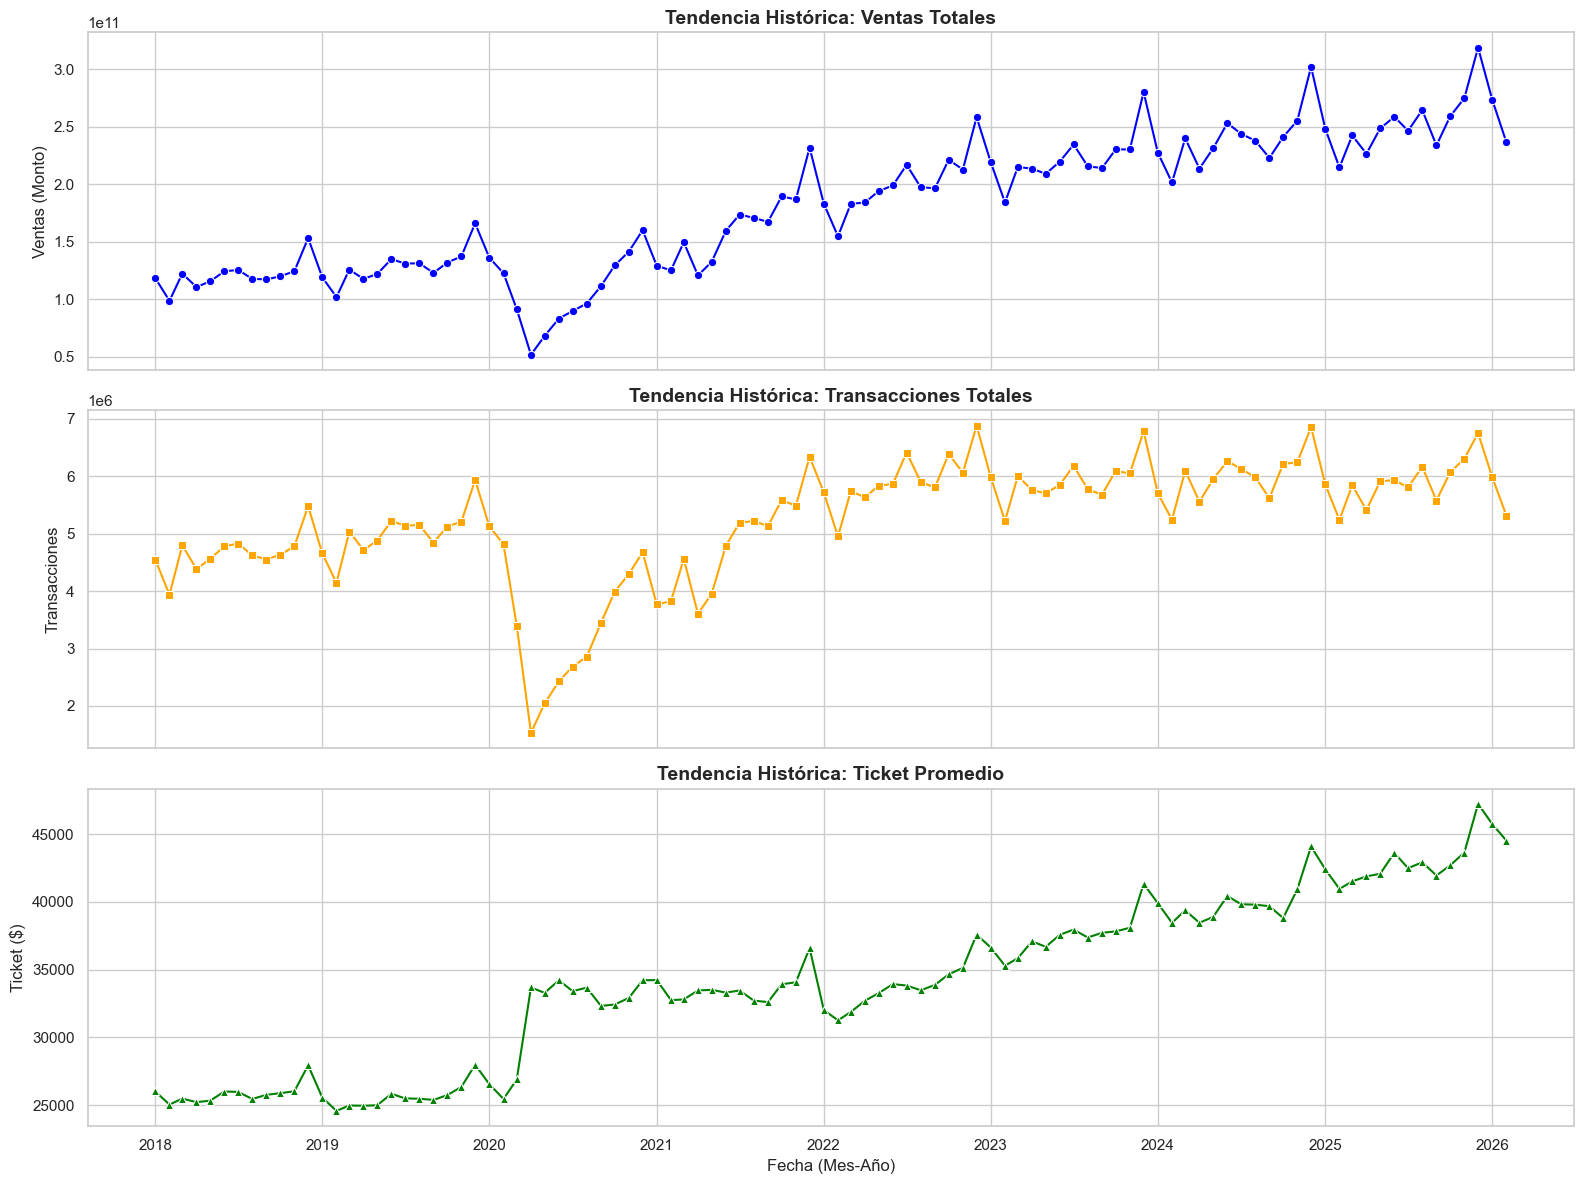

In [8]:
# ==========================================
# A. TENDENCIA HISTÓRICA (MACRO)
# ==========================================
# Agrupamos por fecha para ver el comportamiento total del mercado mes a mes
tendencia_macro = df_master.groupby('fecha').agg({
    'ventas_monto': 'sum',
    'transacciones': 'sum'
}).reset_index()

# Calculamos el ticket promedio a nivel macro para cada mes
tendencia_macro['ticket_promedio'] = np.where(
    tendencia_macro['transacciones'] > 0,
    tendencia_macro['ventas_monto'] / tendencia_macro['transacciones'],
    0
)

# Creamos una figura con 3 subgráficos para comparar los KPIs en la misma línea de tiempo
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# 1. Gráfico de Ventas
sns.lineplot(data=tendencia_macro, x='fecha', y='ventas_monto', ax=axes[0], color='blue', marker='o')
axes[0].set_title('Tendencia Histórica: Ventas Totales', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Ventas (Monto)')

# 2. Gráfico de Transacciones
sns.lineplot(data=tendencia_macro, x='fecha', y='transacciones', ax=axes[1], color='orange', marker='s')
axes[1].set_title('Tendencia Histórica: Transacciones Totales', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Transacciones')

# 3. Gráfico de Ticket Promedio
sns.lineplot(data=tendencia_macro, x='fecha', y='ticket_promedio', ax=axes[2], color='green', marker='^')
axes[2].set_title('Tendencia Histórica: Ticket Promedio', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Ticket ($)')
axes[2].set_xlabel('Fecha (Mes-Año)')

plt.tight_layout()
plt.show()

### Análisis de Tendencia:
* **El Efecto Pandemia (2020):** Se observa una caída abrupta y sin precedentes entre marzo y abril de 2020 en las variables de Ventas y Transacciones, marcando el inicio de las restricciones por COVID-19.
* **Fuerte Correlación y Crecimiento Conjunto (Post-2022):** Al superar la etapa de recuperación, a partir de 2022 las Ventas y las Transacciones muestran un comportamiento casi idéntico y altamente correlacionado. Los picos y valles se sincronizan perfectamente, demostrando que el volumen operativo (tráfico de clientes) es el principal motor de los ingresos. Ambas métricas mantienen una clara tendencia alcista hasta 2026.
* **Efecto Multiplicador del Ticket Promedio:** La métrica del Ticket Promedio explica por qué la pendiente de crecimiento de las Ventas es ligeramente más pronunciada que la de las Transacciones. El ticket pasó de un rango de $32,000 en 2022 a superar los $45,000 en 2025/2026. Conclusión: El sector food service en esta base de datos está experimentando un "doble impulso" muy saludable: están captando un mayor volumen de clientes (más transacciones) y, simultáneamente, facturando más por cada uno de ellos (mayor ticket).

C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_22788\1373317548.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='Mes', y='ventas_monto', showfliers=False, ax=axes[0], palette='Blues')
C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_22788\1373317548.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='Mes', y='transacciones', showfliers=False, ax=axes[1], palette='Oranges')
C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_22788\1373317548.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

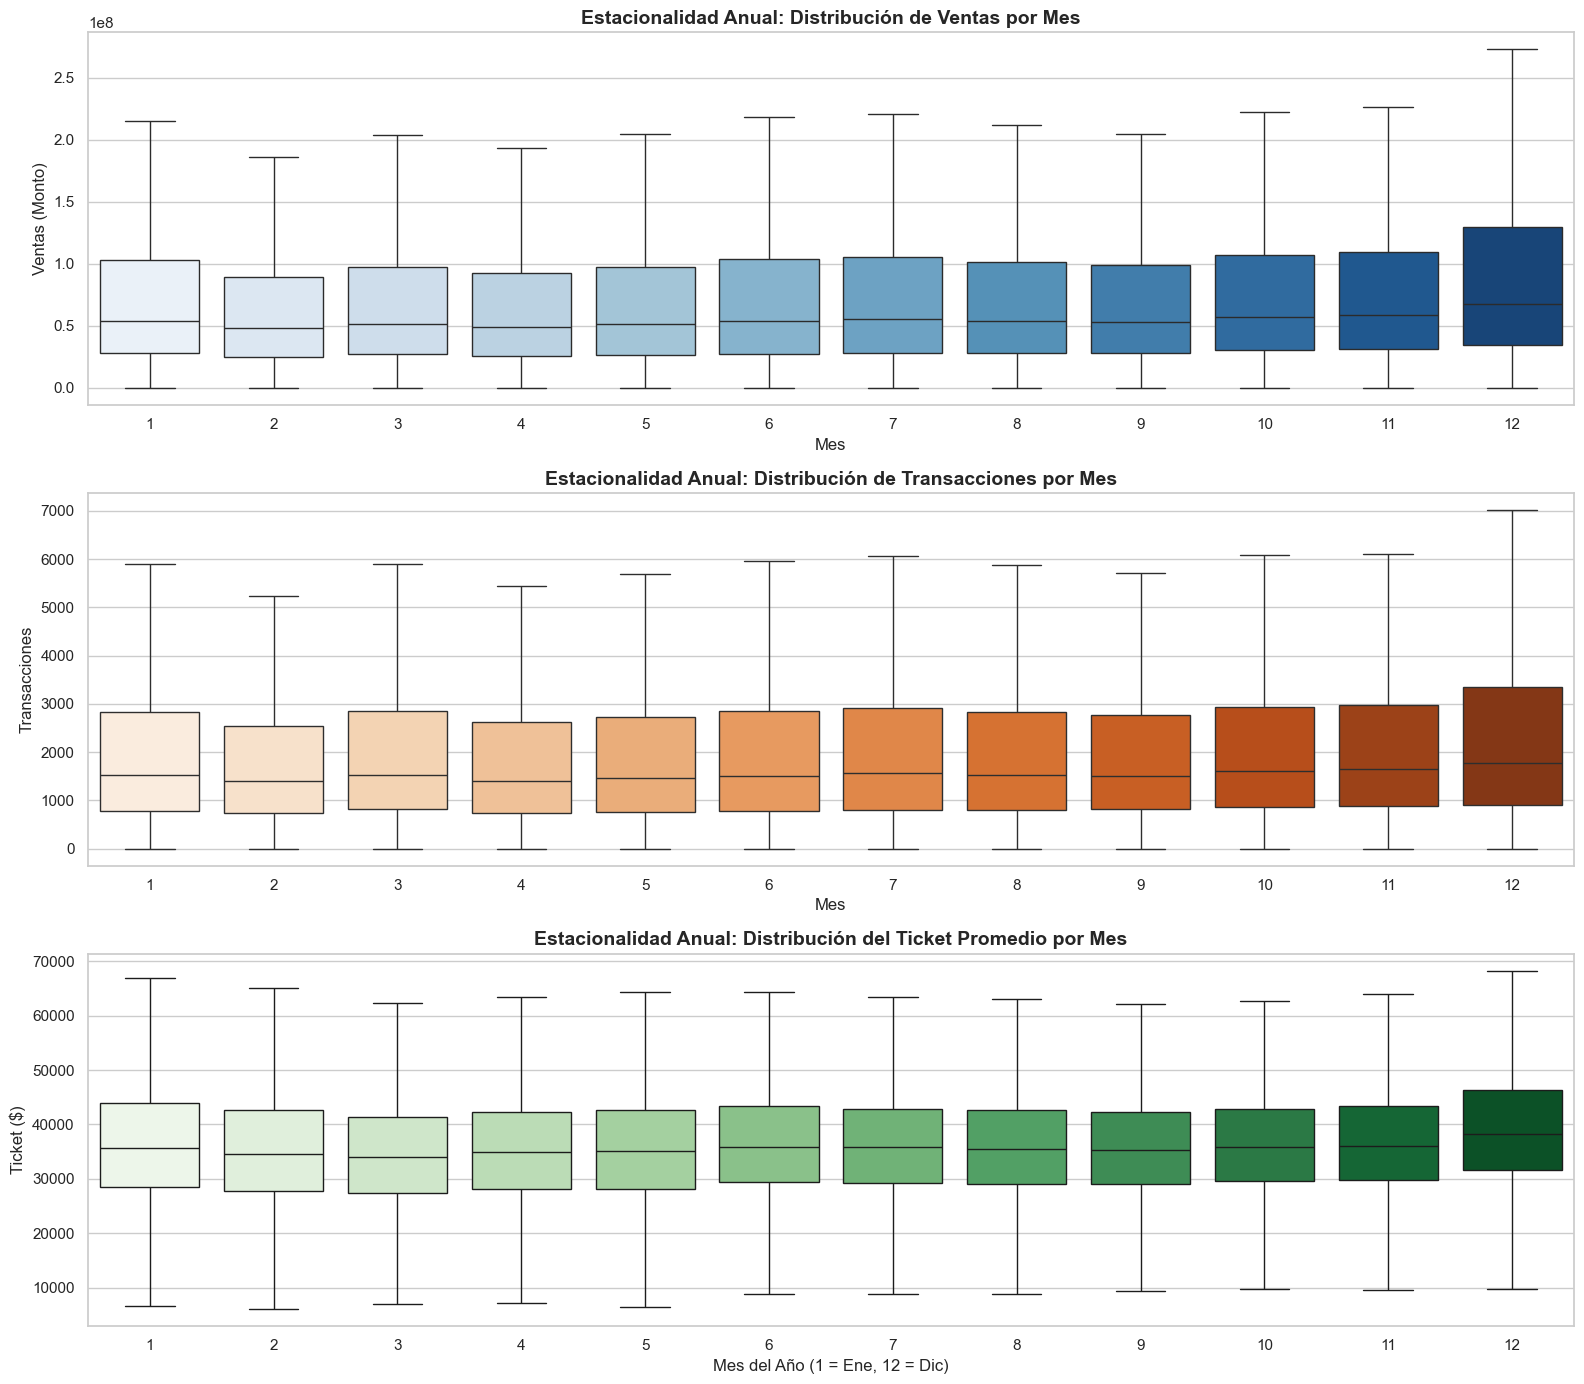

In [9]:
# ==========================================
# B. ESTACIONALIDAD ANUAL (COMPORTAMIENTO MES A MES)
# ==========================================

# Creamos una figura con 3 subgráficos para evaluar la distribución estacional
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# 1. Estacionalidad de Ventas
sns.boxplot(data=df_master, x='Mes', y='ventas_monto', showfliers=False, ax=axes[0], palette='Blues')
axes[0].set_title('Estacionalidad Anual: Distribución de Ventas por Mes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Ventas (Monto)')

# 2. Estacionalidad de Transacciones
sns.boxplot(data=df_master, x='Mes', y='transacciones', showfliers=False, ax=axes[1], palette='Oranges')
axes[1].set_title('Estacionalidad Anual: Distribución de Transacciones por Mes', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Transacciones')

# 3. Estacionalidad del Ticket Promedio
# Filtramos transacciones > 0 para no distorsionar el boxplot del ticket con ceros
df_ticket_valido = df_master[df_master['transacciones'] > 0]
sns.boxplot(data=df_ticket_valido, x='Mes', y='ticket', showfliers=False, ax=axes[2], palette='Greens')
axes[2].set_title('Estacionalidad Anual: Distribución del Ticket Promedio por Mes', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Ticket ($)')
axes[2].set_xlabel('Mes del Año (1 = Ene, 12 = Dic)')

plt.tight_layout()
plt.show()

#### 2. Análisis de Estacionalidad Anual (Patrones Cíclicos)
* **El pico de Diciembre (Mes 12):** Es indiscutiblemente el mes más fuerte del año. Presenta las medianas más altas y los bigotes (*whiskers*) más extensos tanto en Ventas como en Transacciones, lo que indica no solo un mayor volumen base, sino la ocurrencia de días con desempeños extraordinariamente altos.
* **El valle de Febrero (Mes 2):** Históricamente es el mes con menor volumen de Ventas y Transacciones. Esto se explica en gran medida por un efecto calendario (es el mes más corto del año, con 28/29 días) y por la contracción del gasto post-temporada navideña y entrada escolar.
* **Meses de transición y picos intermedios:** Se nota un repunte interesante en el mes de **Mayo (Mes 5)**, altamente correlacionado con festividades clave en Colombia como el Día de la Madre, que moviliza el sector *food service*. Los meses de **Octubre (10) y Noviembre (11)** muestran una rampa de aceleración clara hacia la temporada de fin de año.
* **Estabilidad del Ticket Estacional:** A diferencia de los volúmenes totales que fluctúan drásticamente mes a mes, la caja del Ticket Promedio se mantiene sorprendentemente estable a lo largo del año. Solo se percibe un ligero engrosamiento en diciembre, sugiriendo que el cliente es ligeramente menos sensible al precio o está dispuesto a gastar un poco más en sus celebraciones de fin de año.

# 3. Análisis Exploratorio (EDA) - Segmentación del Negocio 📊

Una vez comprendida la tendencia macro y la estacionalidad, en esta sección profundizaré en cómo se distribuyen las métricas clave a través de las diferentes dimensiones operativas de las marcas.

Dado que en la fase anterior descubrimos la importancia de evaluar simultáneamente el volumen de ingresos, el tráfico y el precio, aplicaré esta misma lógica para analizar:
1. **El peso por Categoría (`categoria_id`):** Para identificar cuáles son los nichos de mercado (ej. hamburguesas, pollo, pizza) que lideran en ventas vs. tráfico.
2. **El desempeño por Tipo de Punto de Venta (`tipo_pdv_id`):** Para entender si los formatos físicos (ej. Centro comercial, Calle, Terminales) tienen patrones de demanda o tickets promedio distintos.

C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_22788\2026303436.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_categoria, x='categoria_id', y='ventas_totales', ax=axes[0], palette='Blues_r')
C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_22788\2026303436.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_categoria, x='categoria_id', y='transacciones_totales', ax=axes[1], palette='Oranges_r')
C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_22788\2026303436.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the

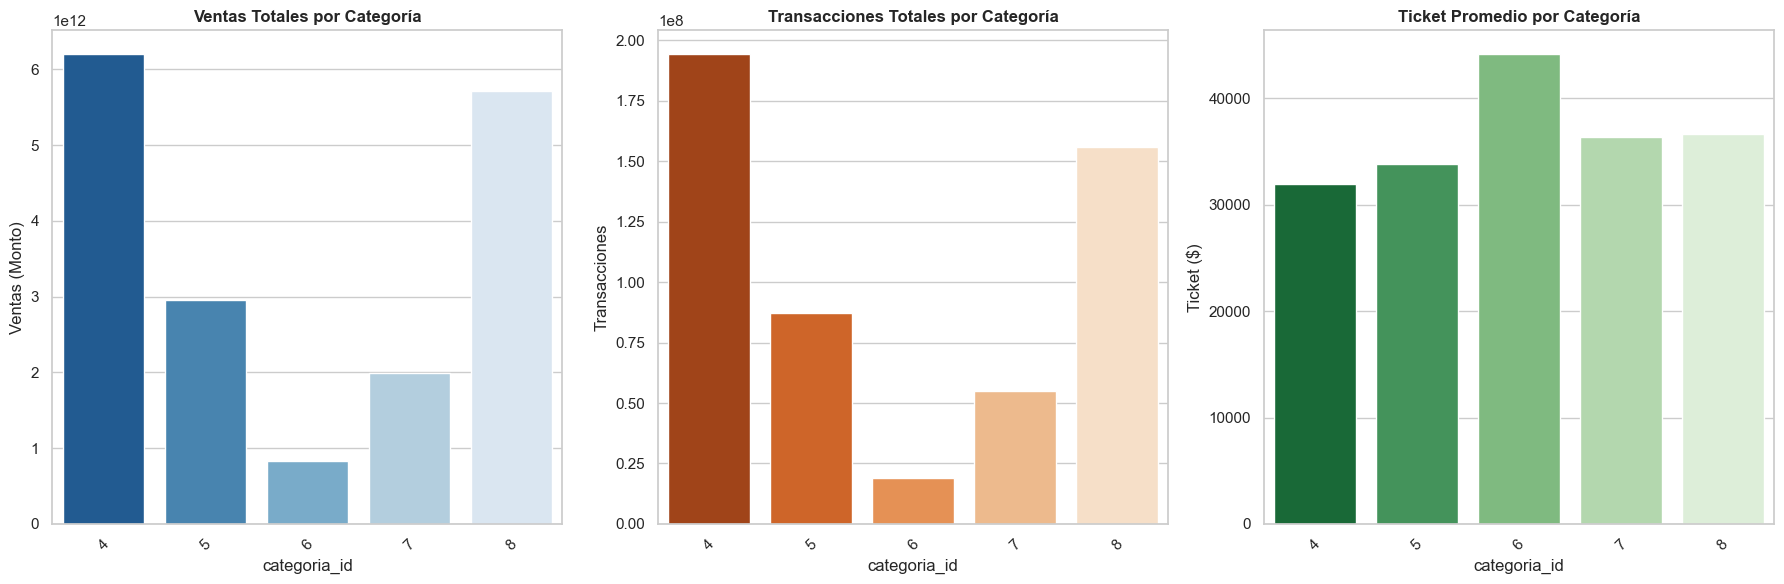

In [10]:
# ==========================================
# A. ANÁLISIS POR CATEGORÍA DE COMIDA
# ==========================================
# Agrupamos los datos históricos totales por categoría
resumen_categoria = df_master.groupby('categoria_id').agg(
    ventas_totales=('ventas_monto', 'sum'),
    transacciones_totales=('transacciones', 'sum')
).reset_index()

# Calculamos el ticket promedio global para cada categoría
resumen_categoria['ticket_promedio'] = np.where(
    resumen_categoria['transacciones_totales'] > 0,
    resumen_categoria['ventas_totales'] / resumen_categoria['transacciones_totales'],
    0
)

# Ordenamos por ventas totales para que la gráfica sea más fácil de leer
resumen_categoria = resumen_categoria.sort_values(by='ventas_totales', ascending=False)

# Creamos una figura con 3 subgráficos horizontales
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Ventas por Categoría
sns.barplot(data=resumen_categoria, x='categoria_id', y='ventas_totales', ax=axes[0], palette='Blues_r')
axes[0].set_title('Ventas Totales por Categoría', fontweight='bold')
axes[0].set_ylabel('Ventas (Monto)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Transacciones por Categoría
sns.barplot(data=resumen_categoria, x='categoria_id', y='transacciones_totales', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Transacciones Totales por Categoría', fontweight='bold')
axes[1].set_ylabel('Transacciones')
axes[1].tick_params(axis='x', rotation=45)

# 3. Ticket Promedio por Categoría
# Ordenamos específicamente por ticket para este gráfico para ver quién es el más caro
resumen_cat_ticket = resumen_categoria.sort_values(by='ticket_promedio', ascending=False)
sns.barplot(data=resumen_cat_ticket, x='categoria_id', y='ticket_promedio', ax=axes[2], palette='Greens_r')
axes[2].set_title('Ticket Promedio por Categoría', fontweight='bold')
axes[2].set_ylabel('Ticket ($)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_22788\3334874595.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_pdv, x='tipo_pdv_id', y='ventas_totales', ax=axes[0], palette='Blues_r')
C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_22788\3334874595.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_pdv, x='tipo_pdv_id', y='transacciones_totales', ax=axes[1], palette='Oranges_r')
C:\Users\Analista GIG Latam\AppData\Local\Temp\ipykernel_22788\3334874595.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


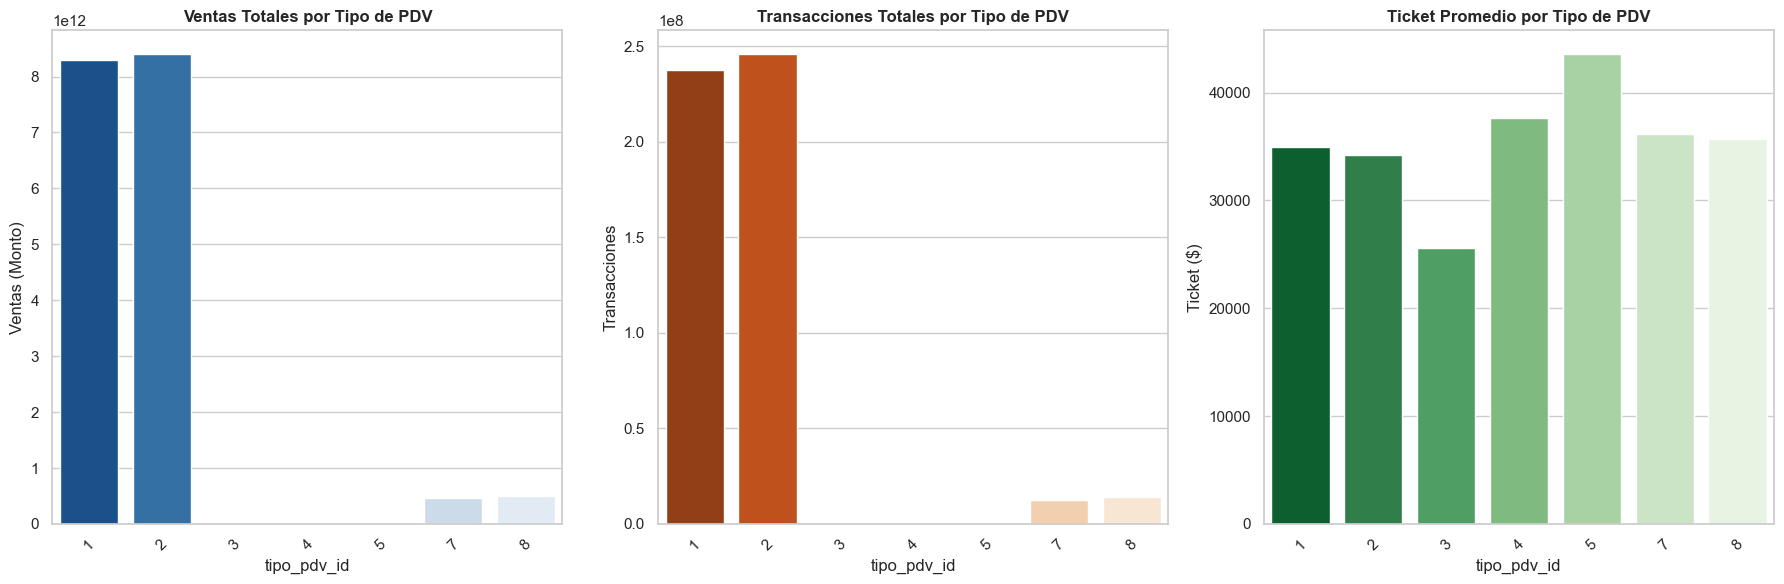

In [11]:
# ==========================================
# B. ANÁLISIS POR TIPO DE PUNTO DE VENTA (PDV)
# ==========================================
# Agrupamos los datos históricos totales por tipo de PDV
resumen_pdv = df_master.groupby('tipo_pdv_id').agg(
    ventas_totales=('ventas_monto', 'sum'),
    transacciones_totales=('transacciones', 'sum')
).reset_index()

# Calculamos el ticket promedio global para cada tipo de PDV
resumen_pdv['ticket_promedio'] = np.where(
    resumen_pdv['transacciones_totales'] > 0,
    resumen_pdv['ventas_totales'] / resumen_pdv['transacciones_totales'],
    0
)

# Ordenamos por ventas totales
resumen_pdv = resumen_pdv.sort_values(by='ventas_totales', ascending=False)

# Creamos una figura con 3 subgráficos horizontales
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Ventas por Tipo de PDV
sns.barplot(data=resumen_pdv, x='tipo_pdv_id', y='ventas_totales', ax=axes[0], palette='Blues_r')
axes[0].set_title('Ventas Totales por Tipo de PDV', fontweight='bold')
axes[0].set_ylabel('Ventas (Monto)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Transacciones por Tipo de PDV
sns.barplot(data=resumen_pdv, x='tipo_pdv_id', y='transacciones_totales', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Transacciones Totales por Tipo de PDV', fontweight='bold')
axes[1].set_ylabel('Transacciones')
axes[1].tick_params(axis='x', rotation=45)

# 3. Ticket Promedio por Tipo de PDV
resumen_pdv_ticket = resumen_pdv.sort_values(by='ticket_promedio', ascending=False)
sns.barplot(data=resumen_pdv_ticket, x='tipo_pdv_id', y='ticket_promedio', ax=axes[2], palette='Greens_r')
axes[2].set_title('Ticket Promedio por Tipo de PDV', fontweight='bold')
axes[2].set_ylabel('Ticket ($)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Hallazgos de la Segmentación Operativa

El análisis transversal de Ventas, Transacciones y Ticket Promedio revela dinámicas de negocio muy marcadas tanto a nivel de producto (Categorías) como de formato físico (Tipo de PDV):

#### 1. Dinámica por Categoría (`categoria_id`): La paradoja del Volumen vs. Precio
* **4: El motor de tráfico.** La categoría 4 es la líder indiscutible en volumen, generando la mayor cantidad de Ventas y Transacciones. Sin embargo, tiene el Ticket Promedio más bajo de todos (cercano a los $31,000). Esto indica que es un producto de consumo masivo, alta rotación y posiblemente dirigido a un segmento sensible al precio o de consumo individual.
* **6: El segmento Premium o Familiar.** Representa exactamente el caso opuesto a 4. Es la categoría con el menor volumen de transacciones y ventas, pero ostenta el Ticket Promedio más alto del mercado (superando los $43,000). Su modelo de negocio no depende del tráfico masivo, sino de un alto desembolso por ocasión.
* **8: El equilibrio ideal.** Esta categoría se posiciona como el segundo formato más fuerte en ingresos y tráfico, pero logra mantener un Ticket Promedio muy competitivo (el segundo más alto, rondando los $36,000). Es, posiblemente, el segmento más rentable y equilibrado del portafolio analizado.

#### 2. Dinámica por Tipo de Punto de Venta (`tipo_pdv_id`): Alta concentración de mercado
* **Concentración extrema en 2 y 1:** El negocio es altamente dependiente de estos dos formatos físicos. 2 y 1 acaparan casi la totalidad de las Ventas y Transacciones del mercado, dejando a los demás formatos (8, 7, 5, etc.) con participaciones marginales. 
* **Formatos de nicho (5 y 4):** Aunque su aporte al volumen total de transacciones es casi invisible en la gráfica, los formatos 5 y 4 dominan absolutamente la gráfica de Ticket Promedio (con 5 superando los $42,000). Esto sugiere que podrían ser ubicaciones exclusivas, puntos de venta en aeropuertos/zonas VIP, o formatos de manteles donde el flujo de clientes es bajo pero el gasto es sustancialmente mayor que en los formatos estándar 2/1.

**Conclusión para el Modelo Predictivo:** Esta segmentación confirma que no podemos predecir el comportamiento de una "marca fantasma" usando promedios globales. Si la nueva marca a predecir (Objetivo 2) pertenece a la categoría 4 y opera en un formato 2, el algoritmo deberá proyectar un volumen altísimo de transacciones pero acotar estrictamente el ticket esperado; caso contrario si pertenece a 6 en formato 5.

In [14]:
df_master.describe 


<bound method NDFrame.describe of             fecha  punto_de_venta_id  canal_id  ventas_monto  transacciones  \
0      2018-01-01                  1         1  1.240734e+08         3257.0   
1      2018-02-01                  1         1  1.059515e+08         2485.0   
2      2018-03-01                  1         1  1.180433e+08         2713.0   
3      2018-04-01                  1         1  1.045680e+08         2428.0   
4      2018-05-01                  1         1  1.071843e+08         2487.0   
...           ...                ...       ...           ...            ...   
210964 2026-02-01               4438         1  5.465045e+07         1956.0   
210965 2026-02-01               4439         1  2.861578e+07          863.0   
210966 2026-02-01               4442         1  3.532387e+07         1093.0   
210967 2026-02-01               4443         1  2.090049e+07          703.0   
210968 2026-02-01               4454         1  5.307845e+07         1580.0   

              tic

In [ ]:
# ==========================================
# EXPORTACIÓN DEL DATASET LIMPIO
# ==========================================
# Guardamos el DataFrame maestro ya depurado para usarlo en el siguiente notebook de modelado
df_master.to_csv('df_master_limpio.csv', index=False)
print("¡Dataset limpio exportado exitosamente como 'df_master_limpio.csv'!")

¡Dataset limpio exportado exitosamente como 'df_master_limpio.csv'!
